In [58]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import pytorch_model_summary
import numpy as np
from scipy import stats
import IGC
import matplotlib.pyplot as plt
import importlib
import pickle
import time
from sklearn.metrics import roc_curve, auc
import copy

importlib.reload(IGC)
torch.cuda.empty_cache()
nsteps = 10 # number of time steps
M=10 # number of signals
conns_list=[5]
nrs=0
np.random.seed(100)
rind=np.random.rand(M).argsort()
conns=[]
receivers=[1,2,3,4,5]
for i, rec in enumerate(receivers):
    conns.append([int(rind[i]), int(rind[-rec])])
n_conns=len(conns)
conns=np.array(conns)
print(conns.T)

rel_unrel=np.zeros(M)
rel_unrel[conns[:,1]]=1
con_rel=np.argwhere(rel_unrel>0).squeeze()
con_unrel=np.argwhere(rel_unrel==0).squeeze()
print(f'Total available number of connectivities: {nConns}')
print(f'Predictable signals: {con_rel}')
print(f'Unpredictable signals: {con_unrel}')
hidden_size=[100,100]

org_con=torch.zeros([M, M])
org_con[conns[:,1],conns[:,0]]=1

[[4 5 8 1 2]
 [3 7 6 9 0]]
Total available number of connectivities: 5
Predictable signals: [0 3 6 7 9]
Unpredictable signals: [1 2 4 5 8]


In [59]:
importlib.reload(IGC)
device='cuda:0'

class MVAR_DMA(nn.Module):
    """ 
    Regression with a multihead attention model
    """
    def __init__(self, input_size, hidden_size, seq_len, num_layers=1):
        super(MVAR_DMA, self).__init__()
        self.seq_len = seq_len
        self.hidden_size = hidden_size
        self.lstm1 = IGC.DM_LSTM(input_size, hidden_size[0], seq_len, num_layers, bidirectional=True)
        # Attention layer
        self.attention_layer = nn.Linear(hidden_size[0]*2, hidden_size[0]*2)
        # Feedforward network
        self.fc1 = nn.Linear(hidden_size[0]*2, hidden_size[1])
        self.fc2 = nn.Linear(hidden_size[1], input_size)
        
    def forward(self, x):
        out          = self.lstm1(x)
        out          = F.tanh(out)
        # Apply attention to each hidden state
        attn_weights = torch.softmax(self.attention_layer(out), dim=1)  # Shape: (batch_size, seq_len, 1)
        weighted_mem = out * attn_weights  # Shape: (batch_size, seq_len, hidden_dim)
        # Aggregate the weighted hidden states
        out          = weighted_mem.sum(dim=1)  # Shape: (batch_size, hidden_dim)
       # Apply layer normalization and feedforward network
        out          = F.tanh(self.fc1(out))
        out          = self.fc2(out)
        
        return out

class MVAR_DMA_fast(nn.Module):
    """ 
    Regression with a multihead attention model
    """
    def __init__(self, input_size, hidden_size, seq_len, num_layers=1):
        super(MVAR_DMA_fast, self).__init__()
        self.seq_len = seq_len
        self.hidden_size = hidden_size
        self.lstm1 = IGC.DM_LSTM_Fast(input_size, hidden_size[0], seq_len, num_layers, bidirectional=True)
        # Attention layer
        self.attention_layer = nn.Linear(hidden_size[0]*2, hidden_size[0]*2)
        # Feedforward network
        self.fc1 = nn.Linear(hidden_size[0]*2, hidden_size[1])
        self.fc2 = nn.Linear(hidden_size[1], input_size)
        
    def forward(self, x):
        out          = self.lstm1(x)
        out          = F.tanh(out)
        # Apply attention to each hidden state
        attn_weights = torch.softmax(self.attention_layer(out), dim=1)  # Shape: (batch_size, seq_len, 1)
        weighted_mem = out * attn_weights  # Shape: (batch_size, seq_len, hidden_dim)
        # Aggregate the weighted hidden states
        out          = weighted_mem.sum(dim=1)  # Shape: (batch_size, hidden_dim)
       # Apply layer normalization and feedforward network
        out          = F.tanh(self.fc1(out))
        out          = self.fc2(out)
        
        return out

hidden_size=[50, 50]
model_dma = MVAR_DMA(M+nrs, hidden_size, nsteps, 1).to(device)
model_dmaf = MVAR_DMA_fast(M+nrs, hidden_size, nsteps, 1).to(device)
print('Model summary (DM+Attention)')
print(pytorch_model_summary.summary(model_dma, torch.zeros(1,nsteps,M+nrs).to(device), max_depth=None, show_input=True))
print('Model summary (DM+Attention:Fast)')
print(pytorch_model_summary.summary(model_dmaf, torch.zeros(1,nsteps,M+nrs).to(device), max_depth=None, show_input=True))

Model summary (DM+Attention)
---------------------------------------------------------------------------------
      Layer (type)                   Input Shape         Param #     Tr. Param #
        LSTMCell-1     [1, 10], [1, 50], [1, 50]          12,400          12,400
        LSTMCell-2     [1, 10], [1, 50], [1, 50]          12,400          12,400
          Linear-3                  [1, 10, 100]          10,100          10,100
          Linear-4                      [1, 100]           5,050           5,050
          Linear-5                       [1, 50]             510             510
Total params: 40,460
Trainable params: 40,460
Non-trainable params: 0
---------------------------------------------------------------------------------
Model summary (DM+Attention:Fast)
-----------------------------------------------------------------------
      Layer (type)         Input Shape         Param #     Tr. Param #
          Linear-1        [1, 10, 100]          10,100          10,100
   

.........Early termination (Total elapsed time: 7.304s)
........Early termination (Total elapsed time: 5.220s)
....IGC computation time: 0.172s
....IGC computation time: 0.157s
00000000000000000000000000000000000000000000000000000000000000000000000000000000
* Number of connectivities: 5 *
00000000000000000000000000000000000000000000000000000000000000000000000000000000
Variables that can be predictable
	DM+Attn       : 0.981
	DM+Attn:fast  : 0.981
Variables that cannot be predictable
	DM+Attn       : 0.027
	DM+Attn:fast  : 0.024
Weight similarity:
* Weight length: 10
Total correlation: DM+Attn  DM+Attn:fast
                  0.963    0.966


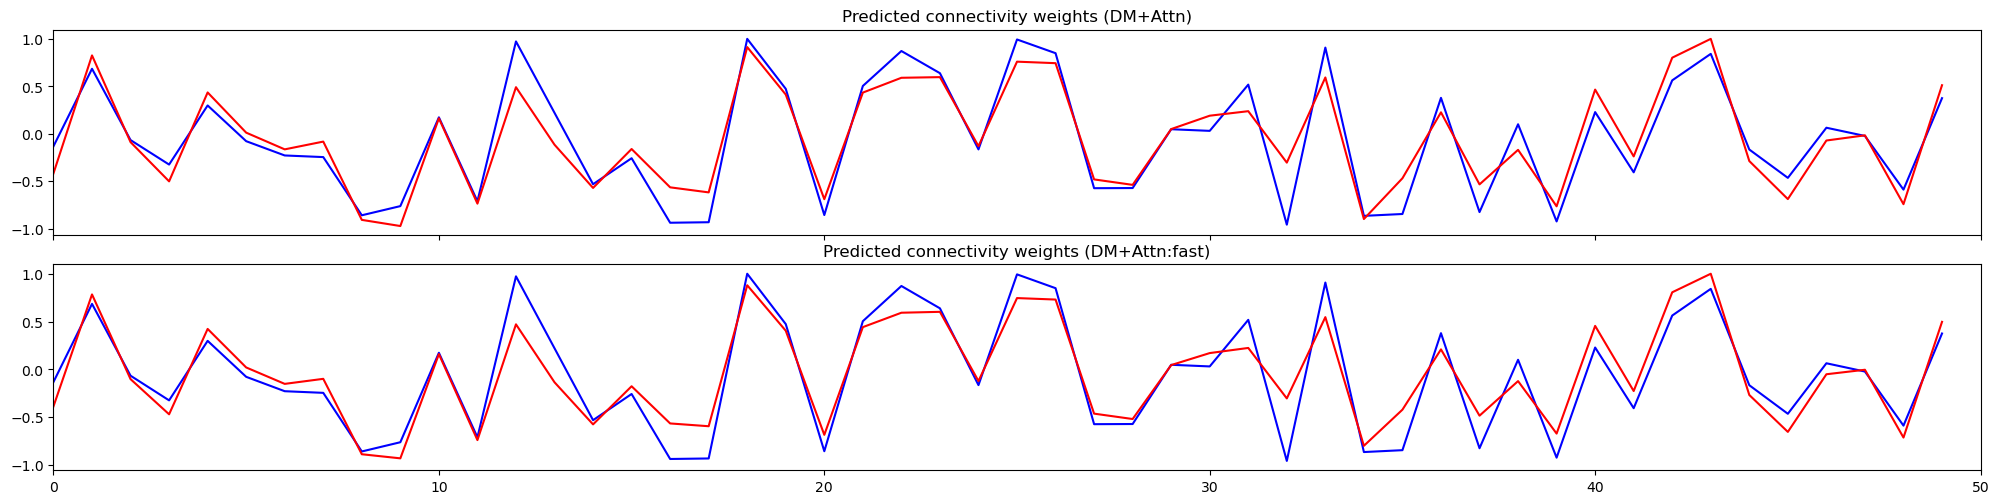

AUC:
	DM+Attn       : 0.998
	DM+Attn:fast  : 0.996
DM+Attn        : 1.000, 1.000, 1.000, 1.000
DM+Attn:fast   : 1.000, 1.000, 1.000, 1.000


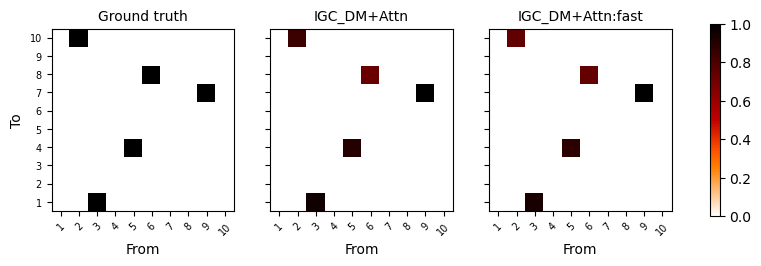

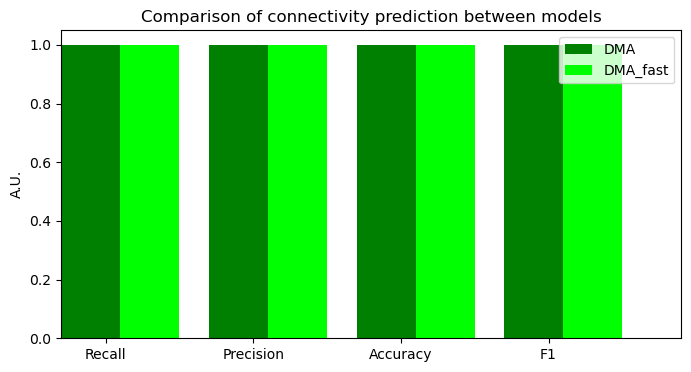

In [60]:
importlib.reload(IGC)
torch.cuda.empty_cache()
results=[]

"""
Signal generation
"""
inc_conns=conns[:n_conns,:]
rel_unrel=np.zeros(M)
rel_unrel[inc_conns[:,1]]=1
con_rel=np.argwhere(rel_unrel>0).squeeze()
con_unrel=np.argwhere(rel_unrel==0).squeeze()
org_con=torch.zeros([M, M])
org_con[inc_conns[:,1],inc_conns[:,0]]=1

x, weights = IGC.simulate_data_random(M, inc_conns, 0.2, order=nsteps, nonlinear=False, fixed_weight=False, sn=10000)
# Add random signals for statistical inference
x = torch.cat([x, torch.randn(x.shape[0], nrs)], axis=1)
# Normalization of input data
for i in range(x.shape[1]):
    x[:,i]=(x[:,i]-torch.mean(x[:,i]))/torch.std(x[:,i])/3.0
# Reconstruction of a dataset with (order) time steps
x_train, y_train = IGC.multivariate_data(x, x, 0, int(x.shape[0]*0.8), nsteps, 1, 1, True)
x_test, y_test = IGC.multivariate_data(x, x, int(x.shape[0]*0.8), int(x.shape[0]), nsteps, 1, 1, True)
x_train = x_train.float()
y_train = y_train.float()
x_test = x_test.float()
y_test = y_test.float()
total_weights=torch.zeros(0)
for i in range(len(weights)):
    total_weights=torch.cat((total_weights, weights[i].flip(0)))
"""
Ensemble prediction (5 repetition)
"""
n_ensembles=1
n_models=2
igc_bundle=torch.zeros([n_ensembles,n_models,M,M])
weight_bundle=torch.zeros([n_ensembles, n_models, nsteps, M+nrs, M+nrs])
ensemble_cor_tot=torch.zeros(n_models)
ensemble_cor=torch.zeros([n_models,M+nrs])
ensemble_y=torch.zeros([n_models,y_test.shape[0],y_test.shape[1]])
for en in range(n_ensembles):
    """
    Define models
    """
    model_dma = MVAR_DMA(M+nrs, hidden_size, nsteps, 1).to(device)
    model_dmaf = MVAR_DMA_fast(M+nrs, hidden_size, nsteps, 1).to(device)
    """
    Train models
    """
    models=[model_dma, model_dmaf]
    for i, model in enumerate(models):
        trainhist, testhist = IGC.train_model(model, (x_train, y_train), (x_test, y_test), 
                                              50, n_batch=100, verbose=False, device=device)
        # Evaluate regression performance at each output
        ensemble_y[i,:,:] += IGC.evaluate_testset(model, (x_test, y_test), nbatch=128)
    """
    Compute gradients
    """
    for i, model in enumerate(models):
        igc = IGC.ig_connectivity(x, model=model, order=nsteps, nrs=nrs, stat='pdc', device=device)
        weight_bundle[en, i, :, :, :] = igc[5]
        igc_bundle[en, i, :, :] = igc[2]
"""
Compute correlation coefficient between predicted and real y_tests
"""
ensemble_y /= n_ensembles
for n_m in range(len(models)):
    for i in range(y_test.shape[-1]):
        ensemble_cor[n_m,i]=torch.corrcoef(torch.stack([ensemble_y[n_m,:,i], y_test[:,i]]))[0,1]
    ensemble_cor_tot[n_m]=torch.corrcoef(torch.stack([ensemble_y[n_m,:,:].reshape(-1),
                                                      y_test.reshape(-1)]))[0,1]
igc_bundle=igc_bundle.mean(0)
weight_bundle=weight_bundle.mean(0)

model_names=['DM+Attn', 'DM+Attn:fast']
print(f'{0:080d}')
print(f'* Number of connectivities: {inc_conns.shape[0]} *')
print(f'{0:080d}')
print('Variables that can be predictable')
for model_name, model_cor in zip(model_names, ensemble_cor):
    print(f'\t{model_name:14s}: {model_cor[con_rel].abs().mean():5.3f}')
print('Variables that cannot be predictable')
for model_name, model_cor in zip(model_names, ensemble_cor):
    print(f'\t{model_name:14s}: {model_cor[con_unrel].abs().mean():5.3f}')
"""
Evaluate estimated weights
"""
print('Weight similarity:')
corr = torch.zeros([n_models,inc_conns.shape[0]])
pred_weights=torch.zeros(0)
for m in range(n_models):
    pred_w=torch.zeros(0)
    for i in range(inc_conns.shape[0]):
        corr[m,i]=torch.corrcoef(torch.stack((weight_bundle[m,:,inc_conns[i,1],inc_conns[i,0]],weights[i].flip(0)),dim=1).T)[0,1]
        pred_w=torch.cat((pred_w, weight_bundle[m,:,inc_conns[i,1],inc_conns[i,0]]))
    pred_weights=torch.cat((pred_weights, pred_w.unsqueeze(0)),dim=0)
print(f'* Weight length: {nsteps}')
print('Total correlation: DM+Attn  DM+Attn:fast')
print('                  {:5.3f}    {:5.3f}'.format(corr[0].mean(),corr[1].mean()))
#print('Total correlation')
# Display predicted weights
fig, ax = plt.subplots(len(model_names), 1, sharex=True, figsize=(20,5))
fig.tight_layout()
for i, (pred_w, label) in enumerate(zip(pred_weights, model_names)):
    ax[i].plot(total_weights/total_weights.abs().max(), 'b', label='Weights')
    ax[i].plot(pred_w/pred_w.abs().max(), color='r', label=label)
    ax[i].set_xlim(0,nsteps*inc_conns.shape[0])
    ax[i].set_title(f'Predicted connectivity weights ({label})')
plt.show()
"""
Connectivity evaluation
"""
print('AUC:')
for i, (igc_res, m_name) in enumerate(zip(igc_bundle, model_names)):
    fpr, tpr, thresh = roc_curve(org_con.flatten(), igc_res.flatten(), pos_label=1)
    auc_value=auc(fpr, tpr)
    print(f'\t{m_name:14s}: {auc_value:5.3f}')
"""
Evaluate prediction metrics
"""
# Display connectivity results
# Scale connectivity
#sig_con[:-2]=np.tanh(np.arctanh(sig_con[:-2])*2)
sig_con=np.array([0.1, 0.1])
con_evals=torch.zeros([igc_bundle.shape[0],4])
thr_cons=[]
for i, (igc_result, sig_level) in enumerate(zip(igc_bundle, sig_con)):
    con_res = torch.diagonal_scatter(igc_result, torch.zeros(igc_result.shape[0]), 0)
    thr_con = F.threshold(con_res, sig_level, 0)
    thr_cons.append(thr_con/thr_con.max())
    con_eval=IGC.evaluate_connectivity_with_hitmap(thr_con, org_con)
    con_evals[i,:]=torch.tensor([con_eval[eval_name] for eval_name in con_eval])
    print(f'{model_names[i]:15s}: {con_evals[i,0]:5.3f}, {con_evals[i,1]:5.3f}, {con_evals[i,2]:5.3f}, {con_evals[i,3]:5.3f}')
# Scale connectivity
IGC.display_connectivity((org_con, thr_cons[0], thr_cons[1]), 
                         title=['Ground truth', 'IGC_DM+Attn', 'IGC_DM+Attn:fast'])
plt.figure(figsize=(8,4))
bar_width=0.4
bar_x=np.arange(4)
plt.bar(bar_x+bar_width*0, con_evals[0], bar_width, color='green', label='DMA')
plt.bar(bar_x+bar_width*1, con_evals[1], bar_width, color='lime', label='DMA_fast')
plt.xlim(-0.2,4.0)
plt.title('Comparison of connectivity prediction between models')
plt.ylabel('A.U.')
plt.xticks(bar_x+0.1, ['Recall', 'Precision', 'Accuracy', 'F1'])
plt.legend()
plt.show()


In [115]:
def train_model_with_connectivity(model, trainset, testset=[], connectivity=None, lam=0.01, 
                                  num_epochs=50, lr=0.001, n_batch=512, verbose=True, device=None):
    if device is None:
        device = ("cuda"
             if torch.cuda.is_available()
             else "mps"
             if torch.backends.mps.is_available()
             else "cpu")
    # 손실 함수와 옵티마이저 정의
    criterion = nn.MSELoss() # 회귀
    testloss = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    # 학습
    if isinstance(trainset, torch.utils.data.DataLoader):
        dataset = trainset
        total_batch = len(dataset)
    else:
        x_train, y_train = trainset
        total_batch = np.ceil(x_train.shape[0]/n_batch).astype(int) # 배치 개수
        x_batch=[]
        y_batch=[]
        for b in range(total_batch):
            x_batch.append(x_train[b*n_batch:(b+1)*n_batch,:,:])
            y_batch.append(y_train[b*n_batch:(b+1)*n_batch,:])
    # CUDA timer
    start = torch.cuda.Event(enable_timing=True)
    end = torch.cuda.Event(enable_timing=True)
    total_s = torch.cuda.Event(enable_timing=True)
    total_e = torch.cuda.Event(enable_timing=True)
    train_hist = np.zeros(0)
    test_hist = np.zeros(0)
    total_s.record()
    for epoch in range(num_epochs):
        start.record()
        avg_cost = 0.0
        avg_pred = 0.0
        avg_sim  = 0.0
        model.train()
        if not isinstance(trainset, torch.utils.data.DataLoader):
            dataset=zip(x_batch, y_batch)
        for i, (x_part, y_part) in enumerate(dataset):
            x_part_dev = x_part.to(device)
            y_part_dev = y_part.to(device)
            if connectivity is not None:
                x_part_dev.requires_grad_(True)
            # 순전파
            outputs = model(x_part_dev)
            pred_loss = criterion(outputs, y_part_dev)
            loss = pred_loss

            # L1-loss 기반 연결성 유사도 손실 추가
            if connectivity is not None:
                proxy_conn_list = []
                # [수정 2] 모든 출력 채널에 대해 반복하여 (Out_Channels, In_Channels) 행렬 생성
                for c in range(outputs.shape[-1]): 
                    # 각 출력 채널 c에 대한 입력의 기울기 계산 (retain_graph=True 필수)
                    grad_c = torch.autograd.grad(outputs[:, c].sum(), x_part_dev, 
                                                 create_graph=True, retain_graph=True)[0]
                    # 시간축(dim=1) 절대값 평균 -> 형태: (Batch, In_Channels)
                    proxy_c = torch.mean(torch.abs(grad_c), dim=1)
                    proxy_conn_list.append(proxy_c)
                
                # 형태 변환: 리스트 -> (Batch, Out_Channels, In_Channels)
                proxy_conn_batch = torch.stack(proxy_conn_list, dim=1)
                # 배치 축(dim=0) 평균 -> 최종 형태: (Out_Channels, In_Channels)
                proxy_conn = torch.mean(proxy_conn_batch, dim=0)

                # L1 Loss 계산
                conn_target = connectivity.to(device)
                off_diag = ~torch.eye(M, dtype=torch.bool, device=device)
                sim_loss = 1.0 - F.cosine_similarity(proxy_conn[off_diag], conn_target[off_diag], dim=0)
                """
                # 임계값(0.5)을 기준으로 가설 행렬의 연결 경로(Positive)와 단절 경로(Negative) 분리
                pos_mask = conn_target > 0.5
                neg_mask = conn_target <= 0.5
                # 방어적 코드: 가설 행렬에 연결된 경로와 단절된 경로가 모두 존재하는 경우
                if pos_mask.sum() > 0 and neg_mask.sum() > 0:
                    # Positive 영역과 Negative 영역의 평균 오차를 각각 독립적으로 계산
                    loss_pos = F.l1_loss(proxy_conn[pos_mask], conn_target[pos_mask])
                    loss_neg = F.l1_loss(proxy_conn[neg_mask], conn_target[neg_mask])
                    # 개수(5개 vs 95개)에 상관없이 두 오차를 1:1 비중으로 합산
                    sim_loss = (loss_pos*2 + loss_neg) / 3.0
                else:
                    # 가설이 전부 0이거나 전부 1인 극단적인 경우에는 기존 L1 Loss 사용
                    sim_loss = F.l1_loss(proxy_conn, conn_target)
                """
                # 최종 Loss (예측 MSE + 람다 * 유사도 L1)
                loss = pred_loss + lam * sim_loss
            # 역전파 & 최적화
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            avg_cost += loss.item()/total_batch
            avg_pred += pred_loss.item()/total_batch
            if connectivity is not None:
                avg_sim  += sim_loss.item()/total_batch
            if (i+1)%10 == 0 and verbose:
                print(f"\r{i+1}/{total_batch}",end=' ')
                progress = int((i+1)/total_batch*100)
                for i in range(progress): print('.',end='')
        if verbose: print("")
        train_hist = np.append(train_hist, [avg_cost, avg_pred, avg_sim])

        if len(testset)>0:
            #testout = model(x_test.to(device))
            testout, tloss = IGC.evaluate_testset(model, testset, testloss, 
                                              nbatch=n_batch, device=device)
            #tloss=testloss(testout, ytest.to(device))
            test_hist = np.append(test_hist, tloss)
            end.record()
            torch.cuda.synchronize()
            if verbose:
                print('Epoch [{}/{}]  Train_loss: {:.5f}  Test_loss: {:.5f}  Elapsed: {:.3f}s'.format(
                    epoch+1, num_epochs, avg_cost, tloss, start.elapsed_time(end)/1000))
            else:
                print('.', end='')
            if epoch>3:
                # test loss가 3회 연속 증가하면 학습 중지
                test_loss_increase=np.array([1 if dif>0 else 0 for dif in test_hist[-3:]-test_hist[-4:-1]])
                if tloss > test_hist[max([epoch-3,0]):epoch].mean() and test_loss_increase.sum()>2:
                    print('Early termination', end=' ')
                    break
        else:
            end.record()
            torch.cuda.synchronize()
            if verbose:
                print('Epoch [{}/{}]  Train_loss: {:.5f}  Elapsed: {:.3f}s'.format(
                    epoch+1, num_epochs, avg_cost, start.elapsed_time(end)/1000))
            else:
                print('.',end='')
    total_e.record()
    torch.cuda.synchronize()
    print('(Total elapsed time: {:.3f}s)'.format(total_s.elapsed_time(total_e)/1000))
    return train_hist, test_hist

In [144]:
margin=0.0
hypo1 = torch.abs(org_con-margin)
hypo2 = torch.zeros_like(hypo1)+margin
hypo2[3,4]+=(1-margin*2)
hypo2[7,5]+=(1-margin*2)
hypo2[6,8]+=(1-margin*2)
hypo2[1,9]+=(1-margin*2)
hypo2[6,3]+=(1-margin*2)
hypo3 = torch.zeros_like(hypo1)+margin
hypo3[1,2]+=(1-margin*2)
hypo3[3,4]+=(1-margin*2)
hypo3[4,0]+=(1-margin*2)
hypo3[2,4]+=(1-margin*2)
hypo3[0,3]+=(1-margin*2)
hypotheses=[hypo1, hypo2, hypo3]

# 모델 학습
total_hist=[]
igcs=[]
model1 = MVAR_DMA_fast(M+nrs, hidden_size, nsteps, 1).to(device)
model2 = MVAR_DMA_fast(M+nrs, hidden_size, nsteps, 1).to(device)
model3 = MVAR_DMA_fast(M+nrs, hidden_size, nsteps, 1).to(device)
models=[model1, model2, model3]
for model, hypo in zip(models, hypotheses):
    trainhist, testhist = train_model_with_connectivity(model, (x_train, y_train), (x_test, y_test), 
                                          connectivity=hypo, lam=0.1, num_epochs=20, n_batch=100, 
                                          verbose=True, device=device)
    total_hist.append([trainhist, testhist])
    igc = IGC.ig_connectivity(x, model=model, order=nsteps, nrs=nrs, stat='pdc', device=device)
    igcs.append(igc)

80/80 ....................................................................................................
Epoch [1/20]  Train_loss: 0.11480  Test_loss: 0.11042  Elapsed: 18.705s
80/80 ....................................................................................................
Epoch [2/20]  Train_loss: 0.10762  Test_loss: 0.10319  Elapsed: 18.716s
80/80 ....................................................................................................
Epoch [3/20]  Train_loss: 0.08481  Test_loss: 0.06471  Elapsed: 18.664s
80/80 ....................................................................................................
Epoch [4/20]  Train_loss: 0.06017  Test_loss: 0.05842  Elapsed: 18.678s
80/80 ....................................................................................................
Epoch [5/20]  Train_loss: 0.05819  Test_loss: 0.05804  Elapsed: 18.647s
80/80 ...................................................................................................

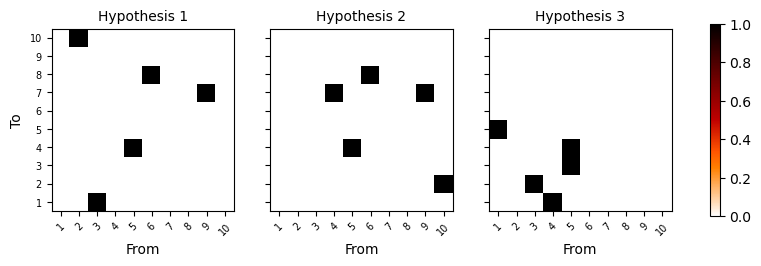

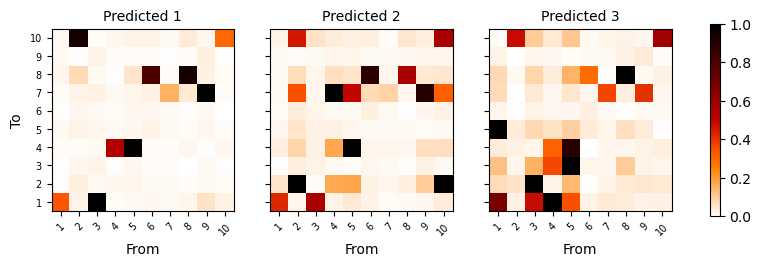

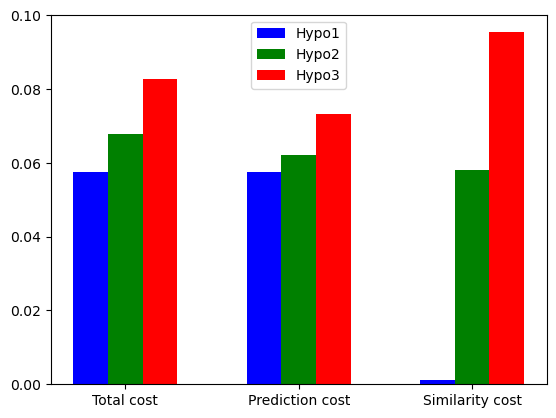

In [147]:
IGC.display_connectivity((hypo1, hypo2, hypo3), 
                         title=['Hypothesis 1', 'Hypothesis 2', 'Hypothesis 3'])
IGC.display_connectivity((igcs[0][2], igcs[1][2], igcs[2][2]), 
                         title=['Predicted 1', 'Predicted 2', 'Predicted 3'])
bar_x=np.arange(3)
plt.bar(bar_x+0,total_hist[0][0][-3:],color='b',width=0.2,label='Hypo1')
plt.bar(bar_x+0.2,total_hist[1][0][-3:],color='g',width=0.2,label='Hypo2')
plt.bar(bar_x+0.4,total_hist[2][0][-3:],color='r',width=0.2,label='Hypo3')
plt.xticks(bar_x+0.2, ['Total cost', 'Prediction cost', 'Similarity cost'])
plt.legend()
plt.show()

In [142]:
def bootstrap_hypothesis_test(model_A, model_B, test_x, test_y, n_iterations=10000, device='cuda'):
    """
    미리 학습된 두 가설 모델의 Test Loss 차이를 부트스트래핑으로 검증합니다.
    """
    model_A.eval()
    model_B.eval()
    criterion = nn.MSELoss(reduction='none') # 평균을 내지 않고 개별 샘플의 Loss를 보존
    
    with torch.no_grad():
        # 1. 무거운 모델 추론 연산은 딱 한 번만 수행합니다.
        pred_A = model_A(test_x.to(device))
        pred_B = model_B(test_x.to(device))
        y_true = test_y.to(device)
        
        # 2. 각 샘플별(시퀀스별) MSE Loss를 미리 다 계산해 둡니다.
        # 형태: (Batch_size, )
        loss_A_all = criterion(pred_A, y_true).mean(dim=(1)).cpu().numpy()
        loss_B_all = criterion(pred_B, y_true).mean(dim=(1)).cpu().numpy()
        
    n_samples = len(loss_A_all)
    diff_distribution = []
    
    # 3. 예측값을 바탕으로 10,000번의 복원 추출(Bootstrapping) 루프를 돕니다.
    print(f"Bootstrapping {n_iterations} iterations...")
    for i in range(n_iterations):
        # 0부터 n_samples-1 사이의 인덱스를 n_samples개 만큼 무작위 복원 추출
        indices = np.random.choice(n_samples, size=n_samples, replace=True)
        
        # 추출된 인덱스로 가상의 테스트 셋 Loss 평균 계산
        boot_loss_A = loss_A_all[indices].mean()
        boot_loss_B = loss_B_all[indices].mean()
        
        # B가 A보다 얼마나 더 안 좋은지(Loss가 큰지) 그 차이를 기록
        diff = boot_loss_B - boot_loss_A
        diff_distribution.append(diff)
        
    diff_distribution = np.array(diff_distribution)
    
    # 4. 통계적 신뢰구간(Confidence Interval) 및 p-value 계산
    # 하위 2.5%, 상위 97.5% 구간 추출 (95% 신뢰구간)
    ci_lower = np.percentile(diff_distribution, 2.5)
    ci_upper = np.percentile(diff_distribution, 97.5)
    
    # B의 Loss가 A의 Loss보다 작게(반대로) 나왔을 확률
    p_value = np.sum(diff_distribution <= 0) / n_iterations
    
    print("-" * 50)
    print("부트스트래핑 검증 결과")
    print(f"가설 B 손실 ({loss_B_all.mean():.5f}) - 가설 A 손실 ({loss_A_all.mean():.5f}) = {diff_distribution.mean():.5f}")
    print(f"95% 신뢰구간 (Confidence Interval): [{ci_lower:.5f}, {ci_upper:.5f}]")
    print(f"p-value: {p_value:.5f}")
    print("-" * 50)

    return diff_distribution

In [149]:
diff_dist = bootstrap_hypothesis_test(model1, model2, x_test, y_test, device=device)

Bootstrapping 10000 iterations...
--------------------------------------------------
부트스트래핑 검증 결과
가설 B 손실 (0.06307) - 가설 A 손실 (0.05795) = 0.00512
95% 신뢰구간 (Confidence Interval): [0.00481, 0.00543]
p-value: 0.00000
--------------------------------------------------
